In [13]:
import pandas as pd
import numpy as np

import torch.nn.functional as F
import torch
from torch.utils.data import Dataset,Subset
import torch.nn as nn
from torch_geometric_temporal.signal import StaticGraphTemporalSignal, temporal_signal_split
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, GCNConv
import matplotlib.pyplot as plt


e:\Supply Graph\.venv3.11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
plant_edges = pd.read_csv("E:\\Supply Graph\\artifacts\\data_ingestion\\edges\\same_plant.csv")
## weight and units Produced
weight_production = pd.read_csv("E:\\Supply Graph\\artifacts\\data_ingestion\\temporal\\weight\\production_weight.csv")
unit_production = pd.read_csv("E:\\Supply Graph\\artifacts\\data_ingestion\\temporal\\unit\\production_unit.csv")

In [15]:
## weights and Units Supplied
weight_sales_order = pd.read_csv("E:\\Supply Graph\\artifacts\\data_ingestion\\temporal\\weight\\sales_order_weight.csv")
unit_sales_order = pd.read_csv("E:\\Supply Graph\\artifacts\\data_ingestion\\temporal\\unit\\sales_order_unit.csv")

In [16]:
## weights and Units Supplied
weight_delivery = pd.read_csv("E:\\Supply Graph\\artifacts\\data_ingestion\\temporal\\weight\\delivery_weight.csv")
unit_delivery = pd.read_csv("E:\\Supply Graph\\artifacts\\data_ingestion\\temporal\\unit\\delivery_unit.csv")

In [17]:
dfs = [weight_production,unit_production,weight_sales_order,unit_sales_order,weight_delivery,unit_delivery]
d = {}
for i in dfs:
    i.drop("Date",axis = 1,inplace = True)
    for i in range(len(weight_production.columns)):
        d[weight_production.columns[i]] = i
for i in dfs:    
    i.rename(columns = d,inplace = True)

In [18]:
d

{'SOS008L02P': 0,
 'SOS005L04P': 1,
 'SOS003L04P': 2,
 'SOS002L09P': 3,
 'SOS001L12P': 4,
 'SOS500M24P': 5,
 'SOS250M48P': 6,
 'SOP001L12P': 7,
 'POV005L04P': 8,
 'POV002L09P': 9,
 'POV001L24P': 10,
 'POV500M24P': 11,
 'POP001L12P': 12,
 'POP015K': 13,
 'SO0005L04P': 14,
 'SO0002L09P': 15,
 'SO0001L12P': 16,
 'SO0500M24P': 17,
 'POP005L04P': 18,
 'POP002L09P': 19,
 'POP001L12P.1': 20,
 'POP500M24P': 21,
 'POPF01L12P': 22,
 'AT5X5K': 23,
 'ATN02K12P': 24,
 'ATN01K24P': 25,
 'MAR02K12P': 26,
 'MAR01K24P': 27,
 'ATWWP002K12P': 28,
 'ATWWP001K24P': 29,
 'MASR025K': 30,
 'MAHS025K': 31,
 'SE500G24P': 32,
 'SE200G24P': 33,
 'ATPPCH5X5K': 34,
 'ATPA1K24P': 35,
 'MAPA1K24P': 36,
 'MAP1K25P': 37,
 'MAC1K25P': 38,
 'EEA500G12P': 39,
 'EEA200G24P': 40}

In [19]:
rolled_prod_wt = weight_production.rolling(window = 30).mean()
rolled_prod_ut = unit_production.rolling(window = 30).mean()
rolled_sales_wt = weight_sales_order.rolling(window = 30).mean()
rolled_sales_ut = unit_sales_order.rolling(window = 30).mean()
rolled_delivered_wt = weight_delivery.rolling(window = 30).mean()
rolled_delivered_ut = unit_delivery.rolling(window = 30).mean()

In [20]:
rolled_prod_wt = weight_production.drop(axis = 0,index = [x for x in range(30)])
rolled_prod_ut = unit_production.drop(axis = 0,index = [x for x in range(30)])
rolled_sales_wt = weight_sales_order.drop(axis = 0,index = [x for x in range(30)])
rolled_sales_ut = unit_sales_order.drop(axis = 0,index = [x for x in range(30)])
rolled_delivered_wt = weight_delivery.drop(axis = 0,index = [x for x in range(30)])
rolled_delivered_ut = unit_delivery.drop(axis = 0,index = [x for x in range(30)])

In [21]:
rolled_prod_wt.reset_index(drop = True,inplace = True)
rolled_prod_ut.reset_index(drop = True,inplace = True)
rolled_sales_wt.reset_index(drop = True,inplace = True)
rolled_sales_ut.reset_index(drop = True,inplace = True)
rolled_delivered_wt.reset_index(drop = True,inplace = True)
rolled_delivered_ut.reset_index(drop = True,inplace = True)


In [22]:
rolled_prod_ut

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,503,12281,30,6701,8497,4008,1,0,300,509,...,6,900,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,1000,17,0,0,0,0,0,0,0
2,1219,11439,0,2597,11063,4046,0,0,400,500,...,0,500,200,0,0,0,0,0,0,0
3,0,2317,0,1392,868,2057,0,0,602,1502,...,50,500,0,0,0,0,0,0,0,0
4,3000,8502,0,5197,9002,3423,0,0,0,0,...,0,1000,199,0,0,0,0,43,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,0,5006,0,5231,5005,1203,0,0,112,1000,...,0,500,80,0,0,0,0,0,0,0
187,1500,3172,0,0,4001,1000,0,504,170,1002,...,500,300,0,0,0,0,0,60,0,0
188,504,1500,1000,0,3004,2000,0,0,350,0,...,50,0,0,0,0,0,0,0,0,0
189,0,0,1519,0,1310,1024,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
rolled_prod_wt

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,7.40416,225.9704,0.33120,110.96856,93.80688,44.24832,0.01104,0.00000,5.4600,8.33742,...,0.15,5.4,0.0000,0,0,0,0.0,0.000,0,0
1,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,...,0.00,6.0,0.0816,0,0,0,0.0,0.000,0,0
2,17.94368,210.4776,0.00000,43.00632,122.13552,44.66784,0.00000,0.00000,7.2800,8.19000,...,0.00,3.0,0.9600,0,0,0,0.0,0.000,0,0
3,0.00000,42.6328,0.00000,23.05152,9.58272,22.70928,0.00000,0.00000,10.9564,24.60276,...,1.25,3.0,0.0000,0,0,0,0.0,0.000,0,0
4,44.16000,156.4368,0.00000,86.06232,99.38208,37.78992,0.00000,0.00000,0.0000,0.00000,...,0.00,6.0,0.9552,0,0,0,0.0,1.032,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,0.00000,92.1104,0.00000,86.62536,55.25520,13.28112,0.00000,0.00000,2.0384,16.38000,...,0.00,3.0,0.3840,0,0,0,0.0,0.000,0,0
187,22.08000,58.3648,0.00000,0.00000,44.17104,11.04000,0.00000,5.56416,3.0940,16.41276,...,12.50,1.8,0.0000,0,0,0,0.0,1.440,0,0
188,7.41888,27.6000,11.04000,0.00000,33.16416,22.08000,0.00000,0.00000,6.3700,0.00000,...,1.25,0.0,0.0000,0,0,0,0.0,0.000,0,0
189,0.00000,0.0000,16.76976,0.00000,14.46240,11.30496,0.00000,0.00000,0.0000,0.00000,...,0.00,0.0,0.0000,0,0,0,0.0,0.000,0,0


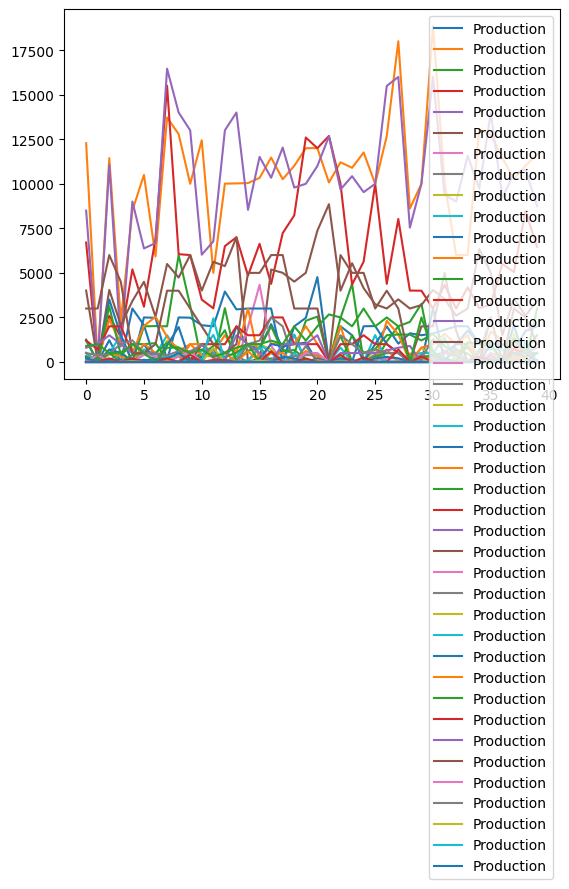

In [24]:
plt.plot(rolled_prod_ut[:40],label = "Production")
plt.legend()
plt.show()

In [25]:
nodes_type_plant_storage = pd.read_csv("E:\\Supply Graph\\artifacts\\data_ingestion\\nodes\\nodes_type_plant_storage.csv")

In [26]:
rolled_delivered_ut

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,792.0,11903.00,1575.0,8391.443961,13380.166033,4929.00000,416.000000,647.000000,545.0,800.0,...,15,811.000,49.0,0,0,0,0,28,0,0.0
1,1221.0,3513.50,262.0,2520.889010,3644.000000,1655.00000,435.000000,0.000000,149.0,383.0,...,11,755.000,0.0,0,0,0,0,0,0,0.0
2,386.0,8917.00,1009.0,7401.000000,10486.000000,3725.00000,501.999004,113.000000,204.0,306.0,...,0,326.000,131.0,0,0,0,0,20,0,0.0
3,377.0,8453.25,1107.0,6328.000000,9985.000000,3439.00000,311.000000,10.000000,288.0,269.0,...,5,169.000,0.0,0,0,0,0,0,0,0.0
4,525.0,5873.00,503.5,5245.550000,5231.416033,2171.61404,266.000000,29.916033,55.0,96.0,...,0,711.330,149.0,0,0,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,606.0,4069.00,651.0,2728.000000,4179.000000,1477.00000,393.999004,15.000000,150.0,287.0,...,91,594.000,131.0,0,0,0,0,0,0,0.0
187,68.0,3419.50,351.0,1909.000000,2722.000000,1179.00000,284.896014,0.000000,265.0,357.0,...,0,238.583,5.0,0,0,0,0,0,0,0.0
188,137.0,6374.75,957.0,4225.000000,5883.000000,2506.00000,243.000000,10.000000,352.0,658.0,...,40,970.000,50.0,0,0,0,0,0,0,0.0
189,130.0,1559.00,155.0,914.000000,1010.000000,500.00000,131.000000,10.000000,140.0,206.0,...,0,212.000,0.0,0,0,0,0,0,0,0.0


In [27]:
nodes_type_plant_storage

,Node,Plant,Storage Location
0,POV002L09P,2120,2030.0
1,SOS001L12P,2120,2030.0
2,POP002L09P,2120,2030.0
3,POP001L12P,2120,2030.0
4,POP001L12P,2120,2030.0
...,...,...,...
6540,MAC1K25P,1915,1530.0
6541,EEA500G12P,2120,2030.0
6542,EEA200G24P,2120,2030.0
6543,EEA500G12P,1920,1130.0


In [28]:
df = pd.read_csv("E:\\Supply Graph\\artifacts\\data_ingestion\\edges\\same_plant.csv")  # columns: Plant, node1, node2

src = torch.tensor(df["node1"].values, dtype=torch.long)
dst = torch.tensor(df["node2"].values, dtype=torch.long)

# undirected version
edge_index = torch.stack(
    [torch.cat([src, dst]), torch.cat([dst, src])],
    dim=0
)

# all nodes that appear in the full graph
nodes = torch.unique(torch.cat([src, dst]))

# later: use NodesIndex.csv to align these ids with your feature matrix X


In [29]:
data = HeteroData()

# 1) Product nodes
nodes_idx = pd.read_csv("E:\\Supply Graph\\artifacts\\data_ingestion\\nodes\\nodes_index.csv")  # gives all product indices
num_prod = len(nodes_idx)
prod_feat_dim = 16  # choose


data['rolled_prod_ut'].x = torch.randn(num_prod, prod_feat_dim)

data['rolled_sales_ut'].x = torch.randn(num_prod, prod_feat_dim)

data['rolled_delivered_ut'].x = torch.randn(num_prod, prod_feat_dim)

def load_edge_index(path):
    df = pd.read_csv(path)           # these have columns: Plant/ProductGroup/etc + node1 + node2
    src = torch.tensor(df['node1'].values, dtype=torch.long)
    dst = torch.tensor(df['node2'].values, dtype=torch.long)
    return torch.stack([src, dst], dim=0)

# 2) Add all relation types

base = "E:\\Supply Graph\\artifacts\\data_ingestion\\edges\\"


## rolled_prod_ut
data['rolled_prod_ut', 'same_plant', 'product'].edge_index = \
    load_edge_index(base + "same_plant.csv")

data['rolled_prod_ut', 'same_storage', 'product'].edge_index = \
    load_edge_index(base + "same_storage.csv")

data['rolled_prod_ut', 'same_product_group', 'product'].edge_index = \
    load_edge_index(base + "same_product_group.csv")

data['rolled_prod_ut', 'same_product_subgroup', 'product'].edge_index = \
    load_edge_index(base + "same_product_subgroup.csv")

## rolled_sales_ut
data['rolled_sales_ut', 'same_plant', 'product'].edge_index = \
    load_edge_index(base + "same_plant.csv")

data['rolled_sales_ut', 'same_storage', 'product'].edge_index = \
    load_edge_index(base + "same_storage.csv")

data['rolled_sales_ut', 'same_product_group', 'product'].edge_index = \
    load_edge_index(base + "same_product_group.csv")

data['rolled_sales_ut', 'same_product_subgroup', 'product'].edge_index = \
    load_edge_index(base + "same_product_subgroup.csv")



## rolled_delivered_ut
data['rolled_delivered_ut', 'same_plant', 'product'].edge_index = \
    load_edge_index(base + "same_plant.csv")

data['rolled_delivered_ut', 'same_storage', 'product'].edge_index = \
    load_edge_index(base + "same_storage.csv")

data['rolled_delivered_ut', 'same_product_group', 'product'].edge_index = \
    load_edge_index(base + "same_product_group.csv")

data['rolled_delivered_ut', 'same_product_subgroup', 'product'].edge_index = \
    load_edge_index(base + "same_product_subgroup.csv")


In [30]:
data

HeteroData(
  rolled_prod_ut={ x=[41, 16] },
  rolled_sales_ut={ x=[41, 16] },
  rolled_delivered_ut={ x=[41, 16] },
  (rolled_prod_ut, same_plant, product)={ edge_index=[2, 1647] },
  (rolled_prod_ut, same_storage, product)={ edge_index=[2, 3046] },
  (rolled_prod_ut, same_product_group, product)={ edge_index=[2, 188] },
  (rolled_prod_ut, same_product_subgroup, product)={ edge_index=[2, 52] },
  (rolled_sales_ut, same_plant, product)={ edge_index=[2, 1647] },
  (rolled_sales_ut, same_storage, product)={ edge_index=[2, 3046] },
  (rolled_sales_ut, same_product_group, product)={ edge_index=[2, 188] },
  (rolled_sales_ut, same_product_subgroup, product)={ edge_index=[2, 52] },
  (rolled_delivered_ut, same_plant, product)={ edge_index=[2, 1647] },
  (rolled_delivered_ut, same_storage, product)={ edge_index=[2, 3046] },
  (rolled_delivered_ut, same_product_group, product)={ edge_index=[2, 188] },
  (rolled_delivered_ut, same_product_subgroup, product)={ edge_index=[2, 52] }
)

In [31]:

prod_ut  = rolled_prod_ut.values.astype(np.float32)
sales_ut = rolled_sales_ut.values.astype(np.float32)
deliv_ut = rolled_delivered_ut.values.astype(np.float32)

# Stack into channels → [T, N, 6]
values_all = np.stack(
    [ prod_ut, sales_ut, deliv_ut],
    axis=-1
)



In [32]:
T,N,C = values_all.shape

P = 12   # history length (example)
Q = 10   # forecast horizon
X_list, Y_list = [], []

for t in range(T - P - Q + 1):
    # Past P steps as input
    x_seq = values_all[t : t + P]          # [P, N, 6]
    # Next Q steps as target
    y_seq = values_all[t + P : t + P + Q]  # [Q, N, 6]

    X_list.append(x_seq)
    Y_list.append(y_seq)

X = np.stack(X_list, axis=0)  # [S, P, N, 6]
Y = np.stack(Y_list, axis=0)  # [S, Q, N, 6]


features = X          # [T-1, N, 6]
targets  = Y          # [T-1, N, 6]


In [33]:
edge_indices = []
for _, ei in data.edge_index_dict.items():
    edge_indices.append(ei)
edge_index_homo = torch.cat(edge_indices, dim=1)  # [2, E_total]
edge_index_np = edge_index_homo.cpu().numpy()
edge_weight = np.ones((edge_index_np.shape[1], 1), dtype=np.float32)

In [34]:

train_ratio = 0.8
S = X.shape[0]
S_train = int(S * train_ratio)

# 1) Split raw into train/test first
X_train_raw = X[:S_train]        # [S_train, P, N, 6]
Y_train_raw = Y[:S_train]        # [S_train, Q, N, 6]
X_test_raw  = X[S_train:]        # [S - S_train, P, N, 6]
Y_test_raw  = Y[S_train:]        # [S - S_train, Q, N, 6]

# 2) Compute stats on *train* only
X_mean = X_train_raw.mean(axis=(0, 1, 2))         # [6]
X_std  = X_train_raw.std(axis=(0, 1, 2)) + 1e-8

Y_mean = Y_train_raw.mean(axis=(0, 1, 2))         # [6]
Y_std  = Y_train_raw.std(axis=(0, 1, 2)) + 1e-8

# 3) Normalize using those stats
X_train_norm = (X_train_raw - X_mean) / X_std     # [S_train, P, N, 6]
Y_train_norm = (Y_train_raw - Y_mean) / Y_std

X_test_norm  = (X_test_raw  - X_mean) / X_std     # IMPORTANT: use train stats
Y_test_norm  = (Y_test_raw  - Y_mean) / Y_std
class SupplyMultiStepDataset(Dataset):
    def __init__(self, X_norm, Y_norm):
        self.X = torch.from_numpy(X_norm).float()  # [S, P, N, 6]
        self.Y = torch.from_numpy(Y_norm).float()  # [S, Q, N, 6]

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_dataset = SupplyMultiStepDataset(X_train_norm, Y_train_norm)
test_dataset  = SupplyMultiStepDataset(X_test_norm,  Y_test_norm)

from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False)


In [37]:
class DeepGCNGRUCell(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        # Two GCN layers (spatial)
        self.gcn1 = GCNConv(in_channels, hidden_channels)
        self.gcn2 = GCNConv(hidden_channels, hidden_channels)

        # Two GRU layers (temporal)
        self.gru1 = nn.GRUCell(hidden_channels, hidden_channels)
        self.gru2 = nn.GRUCell(hidden_channels, hidden_channels)
        self.gru3 = nn.GRUCell(hidden_channels, hidden_channels)

    def forward(self, x, edge_index, h1, h2,h3):
        """
        x:  [B*N, in_channels]
        h1: [B*N, hidden_channels] or None
        h2: [B*N, hidden_channels] or None
        edge_index: [2, E]
        """
        # 2-layer GCN (spatial)
        self.dropout = nn.Dropout(p=0.2)
        x = self.gcn1(x, edge_index)          # [B*N, H]
        x = F.relu(x)
        x = self.gcn2(x, edge_index)          # [B*N, H]
        x = F.relu(x)

        if h1 is None:
            h1 = torch.zeros_like(x)
        if h2 is None:
            h2 = torch.zeros_like(x)
        if h3 is None:
            h3 = torch.zeros_like(x)
        # 2-layer GRU (temporal)
        h1 = self.gru1(x, h1)                 # [B*N, H]
        h2 = self.gru2(h1, h2)
        h3 = self.gru3(h2,h3)                # [B*N, H]

        return h1, h2,h3

class MultiStepDeepGCNGRU(nn.Module):
    def __init__(self, in_channels=6, hidden_channels=64, out_channels=6):
        super().__init__()
        self.cell = DeepGCNGRUCell(in_channels, hidden_channels)
        self.proj = nn.Linear(hidden_channels, out_channels)

    def forward(self, x_seq, edge_index, H):
        """
        x_seq: [B, P, N, in_channels]
        edge_index: [2, E]
        H: forecast horizon (Q)
        returns: [B, H, N, out_channels]
        """
        B, P, N, C = x_seq.shape
        device = x_seq.device
        Hdim = self.proj.in_features  # hidden_channels

        # Initialize hidden states for the two GRU layers
        h1 = torch.zeros(B * N, Hdim, device=device)
        h2 = torch.zeros(B * N, Hdim, device=device)
        h3 = torch.zeros(B * N, Hdim, device=device)

        # Encode history
        for t in range(P):
            x_t = x_seq[:, t]           # [B, N, C]
            x_t = x_t.reshape(B * N, C) # flatten batch+nodes
            h1, h2,h3 = self.cell(x_t, edge_index, h1, h2,h3)

        # Decode H steps autoregressively
        preds = []
        x_dec = x_seq[:, -1]            # [B, N, C] last observed step

        for _ in range(H):
            x_t = x_dec.reshape(B * N, C)
            h1, h2,h3 = self.cell(x_t, edge_index, h1, h2,h3)   # [B*N, H], [B*N, H]
            y_t = self.proj(h2)                           # [B*N, out_channels]
            y_t = y_t.reshape(B, N, -1)                   # [B, N, out_channels]
            preds.append(y_t)
            x_dec = y_t                                   # feed prediction as next input

        preds = torch.stack(preds, dim=1)                  # [B, H, N, out_channels]
        return preds
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
edge_index = edge_index_homo.to(device)
model = MultiStepDeepGCNGRU(in_channels=3, hidden_channels=256, out_channels=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
Q = Y.shape[1]  # 10
for epoch in range(50):
    model.train()
    total_loss = 0.0
    n_train = 0

    if len(train_loader) == 0:
        raise RuntimeError("train_loader is empty; check X_train_norm/Y_train_norm shapes")

    for x_seq, y_seq in train_loader:
        x_seq = x_seq.to(device)   # [B, P, N, 6]
        y_seq = y_seq.to(device)   # [B, Q, N, 6]

        optimizer.zero_grad()
        y_hat = model(x_seq, edge_index, H=Q)   # [B, Q, N, 6]

        loss = criterion(y_hat, y_seq)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_seq.size(0)
        n_train += x_seq.size(0)

    avg_loss = total_loss / n_train
    print(f"Epoch {epoch+1}, train MSE: {avg_loss:.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    total_loss = 0.0
    n_test = 0

    if len(test_loader) == 0:
        raise RuntimeError("test_loader is empty; check X_test_norm/Y_test_norm shapes")

    for x_seq, y_seq in test_loader:
        x_seq = x_seq.to(device)
        y_seq = y_seq.to(device)
        y_hat = model(x_seq, edge_index, H=Q)
        loss = criterion(y_hat, y_seq)
        total_loss += loss.item() * x_seq.size(0)
        n_test += x_seq.size(0)

    print(f"Test MSE: {total_loss / n_test:.4f}")



Epoch 1, train MSE: 0.7144
Epoch 2, train MSE: 0.5746
Epoch 3, train MSE: 0.5114
Epoch 4, train MSE: 0.4832
Epoch 5, train MSE: 0.4642
Epoch 6, train MSE: 0.4475
Epoch 7, train MSE: 0.4777
Epoch 8, train MSE: 0.4830
Epoch 9, train MSE: 0.4514
Epoch 10, train MSE: 0.4456
Epoch 11, train MSE: 0.4746
Epoch 12, train MSE: 0.4737
Epoch 13, train MSE: 0.4583
Epoch 14, train MSE: 0.4358
Epoch 15, train MSE: 0.4201


KeyboardInterrupt: 

10

In [166]:

import numpy as np
import torch

def evaluate_original_units(model, test_loader, edge_index, Q, device, Y_mean, Y_std):
    model.eval()
    mse_sum = 0.0
    mae_sum = 0.0
    se_sum  = 0.0
    st_sum  = 0.0
    n = 0

    Y_mean_t = torch.from_numpy(Y_mean).float().to(device)  # [6]
    Y_std_t  = torch.from_numpy(Y_std).float().to(device)   # [6]

    with torch.no_grad():
        for x_seq, y_seq_norm in test_loader:
            x_seq = x_seq.to(device)           # [B, P, N, 6]
            y_seq_norm = y_seq_norm.to(device) # [B, Q, N, 6]

            y_hat_norm = model(x_seq, edge_index, H=Q)      # [B, Q, N, 6]

            # Denormalize: y = y_norm * std + mean
            y_true = y_seq_norm * Y_std_t + Y_mean_t        # [B, Q, N, 6]
            y_pred = y_hat_norm * Y_std_t + Y_mean_t        # [B, Q, N, 6]

            y_true_flat = y_true.reshape(-1)
            y_pred_flat = y_pred.reshape(-1)

            mse = torch.mean((y_pred_flat - y_true_flat) ** 2)
            mae = torch.mean(torch.abs(y_pred_flat - y_true_flat))

            mse_sum += mse.item() * y_true_flat.numel()
            mae_sum += mae.item() * y_true_flat.numel()

            y_mean = torch.mean(y_true_flat)
            se = torch.sum((y_pred_flat - y_true_flat) ** 2)
            st = torch.sum((y_true_flat - y_mean) ** 2)

            se_sum += se.item()
            st_sum += st.item()
            n += y_true_flat.numel()

    mse_global = mse_sum / n
    rmse_global = np.sqrt(mse_global)
    mae_global = mae_sum / n
    r2_global = 1.0 - (se_sum / st_sum) if st_sum > 0 else 0.0

    return mse_global, rmse_global, mae_global, r2_global

mse, rmse, mae, r2 = evaluate_original_units(
    model, test_loader, edge_index, Q, device, Y_mean, Y_std
)
print(f"Test MSE (orig):  {mse:.4f}")
print(f"Test RMSE (orig): {rmse:.4f}")
print(f"Test MAE (orig):  {mae:.4f}")
print(f"Test R2 (orig):   {r2:.4f}")


Test MSE (orig):  818775.1838
Test RMSE (orig): 904.8620
Test MAE (orig):  277.5793
Test R2 (orig):   0.4762


In [167]:
import numpy as np
import torch

metric_names = ["prod_wt", "prod_ut", "sales_wt", "sales_ut", "deliv_wt", "deliv_ut"]

def evaluate_per_metric_original(model, test_loader, edge_index, Q, device, Y_mean, Y_std):
    model.eval()

    K = len(metric_names)
    mse_sum = np.zeros(K)
    mae_sum = np.zeros(K)
    se_sum  = np.zeros(K)
    st_sum  = np.zeros(K)
    n_sum   = np.zeros(K)

    Y_mean_t = torch.from_numpy(Y_mean).float().to(device)  # [6]
    Y_std_t  = torch.from_numpy(Y_std).float().to(device)   # [6]

    with torch.no_grad():
        for x_seq, y_seq_norm in test_loader:
            x_seq = x_seq.to(device)
            y_seq_norm = y_seq_norm.to(device)

            y_hat_norm = model(x_seq, edge_index, H=Q)      # [B, Q, N, 6]

            # Denormalize to original units
            y_true = y_seq_norm * Y_std_t + Y_mean_t        # [B, Q, N, 6]
            y_pred = y_hat_norm * Y_std_t + Y_mean_t

            for k in range(K):
                y_true_k = y_true[..., k].reshape(-1)
                y_pred_k = y_pred[..., k].reshape(-1)

                mse_k = torch.mean((y_pred_k - y_true_k) ** 2)
                mae_k = torch.mean(torch.abs(y_pred_k - y_true_k))

                mse_sum[k] += mse_k.item() * y_true_k.numel()
                mae_sum[k] += mae_k.item() * y_true_k.numel()
                n_sum[k]   += y_true_k.numel()

                y_mean_k = torch.mean(y_true_k)
                se_k = torch.sum((y_pred_k - y_true_k) ** 2)
                st_k = torch.sum((y_true_k - y_mean_k) ** 2)
                se_sum[k] += se_k.item()
                st_sum[k] += st_k.item()

    for k, name in enumerate(metric_names):
        mse_k = mse_sum[k] / n_sum[k]
        rmse_k = np.sqrt(mse_k)
        mae_k = mae_sum[k] / n_sum[k]
        r2_k = 1.0 - (se_sum[k] / st_sum[k]) if st_sum[k] > 0 else 0.0
        print(f"{name}: RMSE={rmse_k:.2f}, MAE={mae_k:.2f}, R2={r2_k:.3f}")

# Call after training:
evaluate_per_metric_original(model, test_loader, edge_index, Q, device, Y_mean, Y_std)


prod_wt: RMSE=25.25, MAE=10.45, R2=0.310
prod_ut: RMSE=1534.37, MAE=650.67, R2=0.278
sales_wt: RMSE=20.54, MAE=8.72, R2=0.511
sales_ut: RMSE=1268.35, MAE=539.56, R2=0.479
deliv_wt: RMSE=15.97, MAE=7.19, R2=0.600
deliv_ut: RMSE=973.83, MAE=448.89, R2=0.572


In [127]:
prod_ut

array([[  503., 12281.,    30., ...,     0.,     0.,     0.],
       [    0.,     0.,     0., ...,     0.,     0.,     0.],
       [ 1219., 11439.,     0., ...,     0.,     0.,     0.],
       ...,
       [  504.,  1500.,  1000., ...,     0.,     0.,     0.],
       [    0.,     0.,  1519., ...,     0.,     0.,     0.],
       [    0.,     0.,     0., ...,     0.,     0.,     0.]],
      shape=(191, 41), dtype=float32)

# production unit forcaster

In [168]:
data1 = HeteroData()

# 1) Product nodes
nodes_idx = pd.read_csv("E:\\Supply Graph\\artifacts\\data_ingestion\\nodes\\nodes_index.csv")  # gives all product indices
num_prod = len(nodes_idx)
prod_feat_dim = 16  # choose

data['rolled_prod_wt'].x = torch.randn(num_prod, prod_feat_dim)
data['rolled_prod_ut'].x = torch.randn(num_prod, prod_feat_dim)


def load_edge_index(path):
    df = pd.read_csv(path)           # these have columns: Plant/ProductGroup/etc + node1 + node2
    src = torch.tensor(df['node1'].values, dtype=torch.long)
    dst = torch.tensor(df['node2'].values, dtype=torch.long)
    return torch.stack([src, dst], dim=0)

# 2) Add all relation types

base = "E:\\Supply Graph\\artifacts\\data_ingestion\\edges\\"

## rolled_prod_wt
data['rolled_prod_wt', 'same_plant', 'product'].edge_index = \
    load_edge_index(base + "same_plant.csv")

data['rolled_prod_wt', 'same_storage', 'product'].edge_index = \
    load_edge_index(base + "same_storage.csv")

data['rolled_prod_wt', 'same_product_group', 'product'].edge_index = \
    load_edge_index(base + "same_product_group.csv")

data['rolled_prod_wt', 'same_product_subgroup', 'product'].edge_index = \
    load_edge_index(base + "same_product_subgroup.csv")

## rolled_prod_ut
data['rolled_prod_ut', 'same_plant', 'product'].edge_index = \
    load_edge_index(base + "same_plant.csv")

data['rolled_prod_ut', 'same_storage', 'product'].edge_index = \
    load_edge_index(base + "same_storage.csv")

data['rolled_prod_ut', 'same_product_group', 'product'].edge_index = \
    load_edge_index(base + "same_product_group.csv")

data['rolled_prod_ut', 'same_product_subgroup', 'product'].edge_index = \
    load_edge_index(base + "same_product_subgroup.csv")



In [170]:
prod_wt  = rolled_prod_wt.values.astype(np.float32)
prod_ut  = rolled_prod_ut.values.astype(np.float32)
values_all = np.stack(
    [prod_wt, prod_ut],
    axis=-1
)

In [ ]:
T,N,C = values_all.shape

P = 12   # history length (example)
Q = 10   # forecast horizon
X_list, Y_list = [], []

for t in range(T - P - Q + 1):
    # Past P steps as input
    x_seq = values_all[t : t + P]          # [P, N, 2]
    # Next Q steps as target
    y_seq = values_all[t + P : t + P + Q]  # [Q, N, 2]

    X_list.append(x_seq)
    Y_list.append(y_seq)

X = np.stack(X_list, axis=0)  # [S, P, N, 2]
Y = np.stack(Y_list, axis=0)  # [S, Q, N, 2]


features = X          # [T-1, N, 2]
targets  = Y  

In [172]:
edge_indices = []
for _, ei in data.edge_index_dict.items():
    edge_indices.append(ei)
edge_index_homo = torch.cat(edge_indices, dim=1)  # [2, E_total]
edge_index_np = edge_index_homo.cpu().numpy()
edge_weight = np.ones((edge_index_np.shape[1], 1), dtype=np.float32)

In [175]:

train_ratio = 0.8
S = X.shape[0]
S_train = int(S * train_ratio)

# 1) Split raw into train/test first
X_train_raw = X[:S_train]        # [S_train, P, N, 2]
Y_train_raw = Y[:S_train]        # [S_train, Q, N, 2]
X_test_raw  = X[S_train:]        # [S - S_train, P, N, 2]
Y_test_raw  = Y[S_train:]        # [S - S_train, Q, N, 2]

# 2) Compute stats on *train* only
X_mean = X_train_raw.mean(axis=(0, 1, 2))         # [2]
X_std  = X_train_raw.std(axis=(0, 1, 2)) + 1e-8

Y_mean = Y_train_raw.mean(axis=(0, 1, 2))         # [2]
Y_std  = Y_train_raw.std(axis=(0, 1, 2)) + 1e-8

# 3) Normalize using those stats
X_train_norm = (X_train_raw - X_mean) / X_std     # [S_train, P, N, 2]
Y_train_norm = (Y_train_raw - Y_mean) / Y_std

X_test_norm  = (X_test_raw  - X_mean) / X_std     # IMPORTANT: use train stats
Y_test_norm  = (Y_test_raw  - Y_mean) / Y_std
class SupplyMultiStepDataset(Dataset):
    def __init__(self, X_norm, Y_norm):
        self.X = torch.from_numpy(X_norm).float()  # [S, P, N, 2]
        self.Y = torch.from_numpy(Y_norm).float()  # [S, Q, N, 2]

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_dataset_prod = SupplyMultiStepDataset(X_train_norm, Y_train_norm)
test_dataset_prod  = SupplyMultiStepDataset(X_test_norm,  Y_test_norm)

from torch.utils.data import DataLoader
train_loader_prod = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader_prod  = DataLoader(test_dataset,  batch_size=8, shuffle=False)


In [179]:
class DeepGCNGRUCell(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        # Two GCN layers (spatial)
        self.gcn1 = GCNConv(in_channels, hidden_channels)
        self.gcn2 = GCNConv(hidden_channels, hidden_channels)

        # Two GRU layers (temporal)
        self.gru1 = nn.GRUCell(hidden_channels, hidden_channels)
        self.gru2 = nn.GRUCell(hidden_channels, hidden_channels)
        self.gru3 = nn.GRUCell(hidden_channels, hidden_channels)

    def forward(self, x, edge_index, h1, h2,h3):
        """
        x:  [B*N, in_channels]
        h1: [B*N, hidden_channels] or None
        h2: [B*N, hidden_channels] or None
        edge_index: [2, E]
        """
        # 2-layer GCN (spatial)
        self.dropout = nn.Dropout(p=0.2)
        x = self.gcn1(x, edge_index)          # [B*N, H]
        x = F.relu(x)
        x = self.gcn2(x, edge_index)          # [B*N, H]
        x = F.relu(x)

        if h1 is None:
            h1 = torch.zeros_like(x)
        if h2 is None:
            h2 = torch.zeros_like(x)
        if h3 is None:
            h3 = torch.zeros_like(x)
        # 2-layer GRU (temporal)
        h1 = self.gru1(x, h1)                 # [B*N, H]
        h2 = self.gru2(h1, h2)
        h3 = self.gru3(h2,h3)                # [B*N, H]

        return h1, h2,h3

class MultiStepDeepGCNGRU(nn.Module):
    def __init__(self, in_channels=6, hidden_channels=64, out_channels=6):
        super().__init__()
        self.cell = DeepGCNGRUCell(in_channels, hidden_channels)
        self.proj = nn.Linear(hidden_channels, out_channels)

    def forward(self, x_seq, edge_index, H):
        """
        x_seq: [B, P, N, in_channels]
        edge_index: [2, E]
        H: forecast horizon (Q)
        returns: [B, H, N, out_channels]
        """
        B, P, N, C = x_seq.shape
        device = x_seq.device
        Hdim = self.proj.in_features  # hidden_channels

        # Initialize hidden states for the two GRU layers
        h1 = torch.zeros(B * N, Hdim, device=device)
        h2 = torch.zeros(B * N, Hdim, device=device)
        h3 = torch.zeros(B * N, Hdim, device=device)

        # Encode history
        for t in range(P):
            x_t = x_seq[:, t]           # [B, N, C]
            x_t = x_t.reshape(B * N, C) # flatten batch+nodes
            h1, h2,h3 = self.cell(x_t, edge_index, h1, h2,h3)

        # Decode H steps autoregressively
        preds = []
        x_dec = x_seq[:, -1]            # [B, N, C] last observed step

        for _ in range(H):
            x_t = x_dec.reshape(B * N, C)
            h1, h2,h3 = self.cell(x_t, edge_index, h1, h2,h3)   # [B*N, H], [B*N, H]
            y_t = self.proj(h2)                           # [B*N, out_channels]
            y_t = y_t.reshape(B, N, -1)                   # [B, N, out_channels]
            preds.append(y_t)
            x_dec = y_t                                   # feed prediction as next input

        preds = torch.stack(preds, dim=1)                  # [B, H, N, out_channels]
        return preds
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
edge_index = edge_index_homo.to(device)
model = MultiStepDeepGCNGRU(in_channels=2, hidden_channels=16, out_channels=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()
Q = Y.shape[1]  # 10
for epoch in range(50):
    model.train()
    total_loss = 0.0
    n_train = 0

    if len(train_loader_prod) == 0:
        raise RuntimeError("train_loader is empty; check X_train_norm/Y_train_norm shapes")

    for x_seq, y_seq in train_loader_prod:
        x_seq = x_seq.to(device)   # [B, P, N, 6]
        y_seq = y_seq.to(device)   # [B, Q, N, 6]

        optimizer.zero_grad()
        y_hat = model(x_seq, edge_index, H=Q)   # [B, Q, N, 6]

        loss = criterion(y_hat, y_seq)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_seq.size(0)
        n_train += x_seq.size(0)

    avg_loss = total_loss / n_train
    print(f"Epoch {epoch+1}, train MSE: {avg_loss:.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    total_loss = 0.0
    n_test = 0

    if len(test_loader) == 0:
        raise RuntimeError("test_loader is empty; check X_test_norm/Y_test_norm shapes")

    for x_seq, y_seq in test_loader_prod:
        x_seq = x_seq.to(device)
        y_seq = y_seq.to(device)
        y_hat = model(x_seq, edge_index, H=Q)
        loss = criterion(y_hat, y_seq)
        total_loss += loss.item() * x_seq.size(0)
        n_test += x_seq.size(0)

    print(f"Test MSE: {total_loss / n_test:.4f}")



Epoch 1, train MSE: 0.8283
Epoch 2, train MSE: 0.6525
Epoch 3, train MSE: 0.5788
Epoch 4, train MSE: 0.5364
Epoch 5, train MSE: 0.5954
Epoch 6, train MSE: 0.5504
Epoch 7, train MSE: 0.5256
Epoch 8, train MSE: 0.5057
Epoch 9, train MSE: 0.4920
Epoch 10, train MSE: 0.4608
Epoch 11, train MSE: 0.4751
Epoch 12, train MSE: 0.4820
Epoch 13, train MSE: 0.5332
Epoch 14, train MSE: 0.4769
Epoch 15, train MSE: 0.4872
Epoch 16, train MSE: 0.4644
Epoch 17, train MSE: 0.4553
Epoch 18, train MSE: 0.4436
Epoch 19, train MSE: 0.4503
Epoch 20, train MSE: 0.4427
Epoch 21, train MSE: 0.4544
Epoch 22, train MSE: 0.4523
Epoch 23, train MSE: 0.4535
Epoch 24, train MSE: 0.4579
Epoch 25, train MSE: 0.4521
Epoch 26, train MSE: 0.4664
Epoch 27, train MSE: 0.4304
Epoch 28, train MSE: 0.4158
Epoch 29, train MSE: 0.4097
Epoch 30, train MSE: 0.4042
Epoch 31, train MSE: 0.4361
Epoch 32, train MSE: 0.4483
Epoch 33, train MSE: 0.4117
Epoch 34, train MSE: 0.4079
Epoch 35, train MSE: 0.4412
Epoch 36, train MSE: 0.4676
E

In [180]:
metric_names = ["prod_wt", "prod_ut"]

def evaluate_per_metric_original(model, test_loader, edge_index, Q, device, Y_mean, Y_std):
    model.eval()

    K = len(metric_names)
    mse_sum = np.zeros(K)
    mae_sum = np.zeros(K)
    se_sum  = np.zeros(K)
    st_sum  = np.zeros(K)
    n_sum   = np.zeros(K)

    Y_mean_t = torch.from_numpy(Y_mean).float().to(device)  # [6]
    Y_std_t  = torch.from_numpy(Y_std).float().to(device)   # [6]

    with torch.no_grad():
        for x_seq, y_seq_norm in test_loader:
            x_seq = x_seq.to(device)
            y_seq_norm = y_seq_norm.to(device)

            y_hat_norm = model(x_seq, edge_index, H=Q)      # [B, Q, N, 6]

            # Denormalize to original units
            y_true = y_seq_norm * Y_std_t + Y_mean_t        # [B, Q, N, 6]
            y_pred = y_hat_norm * Y_std_t + Y_mean_t

            for k in range(K):
                y_true_k = y_true[..., k].reshape(-1)
                y_pred_k = y_pred[..., k].reshape(-1)

                mse_k = torch.mean((y_pred_k - y_true_k) ** 2)
                mae_k = torch.mean(torch.abs(y_pred_k - y_true_k))

                mse_sum[k] += mse_k.item() * y_true_k.numel()
                mae_sum[k] += mae_k.item() * y_true_k.numel()
                n_sum[k]   += y_true_k.numel()

                y_mean_k = torch.mean(y_true_k)
                se_k = torch.sum((y_pred_k - y_true_k) ** 2)
                st_k = torch.sum((y_true_k - y_mean_k) ** 2)
                se_sum[k] += se_k.item()
                st_sum[k] += st_k.item()

    for k, name in enumerate(metric_names):
        mse_k = mse_sum[k] / n_sum[k]
        rmse_k = np.sqrt(mse_k)
        mae_k = mae_sum[k] / n_sum[k]
        r2_k = 1.0 - (se_sum[k] / st_sum[k]) if st_sum[k] > 0 else 0.0
        print(f"{name}: RMSE={rmse_k:.2f}, MAE={mae_k:.2f}, R2={r2_k:.3f}")

# Call after training:
evaluate_per_metric_original(model, test_loader, edge_index, Q, device, Y_mean, Y_std)


prod_wt: RMSE=24.01, MAE=10.61, R2=0.376
prod_ut: RMSE=1473.98, MAE=661.34, R2=0.334


In [1]:
import numpy as np

In [7]:
PREDICTIONS_PATH = "E:\\Supply Graph\\artifacts\\models\\predictions.npy"
TARGETS_PATH = "E:\\Supply Graph\\artifacts\\models\\targets.npy"

In [10]:

preds_raw = np.load(PREDICTIONS_PATH)  # shape (T, 41*3*7) or (T, 123)
targets_raw = np.load(TARGETS_PATH)

In [12]:
preds_raw

array([[ 973.90894,  900.3511 ,  761.7385 , ...,  878.03357,  622.43115,
         551.7666 ],
       [ 330.6186 , 4907.877  ,  744.9069 , ...,  218.93457,  128.85846,
         228.48682],
       [ 320.1324 , 4881.4478 ,  705.6124 , ...,  218.8327 ,  128.83978,
         228.51416],
       ...,
       [1027.1307 ,  816.9863 ,  736.95404, ...,  996.1435 ,  618.49744,
         606.8418 ],
       [ 398.39502, 3731.4575 ,  644.31537, ...,  218.37268,  128.6618 ,
         228.62213],
       [ 430.46503, 3826.3145 ,  665.6603 , ...,  218.38672,  128.65833,
         228.61658]], shape=(35, 861), dtype=float32)